# Coffee Sales Analysis

This dataset provides detail into a cafe's sales throughout the year includes information such as orders, drink name, price, time and cost. The purpose of this project is to explore the dataset and identify any trends/patterns that could be used to gain an insight into the cafe's business. 

The dataset was cleaned and preprocessed for ease of analysis and is available under an open license for research and data analysis purposes. The dataset is provided by a user from Kaggle (https://www.kaggle.com/datasets/navjotkaushal/coffee-sales-dataset). We will be using Python to analyze the dataset and a series of visualisations such as pandas, seaborn, matplotlib and SciPy libraries to answer the following questions:

1. What type of drinks is most popular?
2. Which time of year has the highest sales and are the significiantly different to each other?
3. How are the sales throughout the day?
4. Is there a significant difference in sales between the days of the week?

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import warnings
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
warnings.simplefilter(action='ignore', category=FutureWarning)

## Inspect Data

In [3]:
df = pd.read_csv('Coffee_sales.csv')

In [4]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB


,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


- **hour_of_day**: Hour of purchase (0–23)
- **cash_type**: Mode of payment (cash / card)
- **money**: Transaction amount (in local currency)
- **coffee_name**: Type of coffee purchased (e.g., Latte, Americano, Hot Chocolate)
- **Time_of_Day**: Categorized time of purchase (Morning, Afternoon, Night)
- **Weekday**: Day of the week (e.g., Mon, Tue, …)
- **Month_name**: Month of purchase (e.g., Jan, Feb, Mar)
- **Weekdaysort**: Numeric representation for weekday ordering (1 = Mon, 7 = Sun)
- **Monthsort**: Numeric representation for month ordering (1 = Jan, 12 = Dec)
- **Date**: Date of transaction (YYYY-MM-DD)
- **Time**: Exact time of transaction (HH:MM:SS)

In [5]:
df.describe(include = 'all')

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
count,3547.000000,3547,3547.000000,3547,3547,3547,3547,3547.000000,3547.000000,3547,3547
unique,NaN,1,NaN,8,3,7,12,NaN,NaN,381,3547
top,NaN,card,NaN,Americano with Milk,Afternoon,Tue,Mar,NaN,NaN,2024-10-11,10:15:50.520000
freq,NaN,3547,NaN,809,1205,572,494,NaN,NaN,26,1
mean,14.185791,NaN,31.645216,NaN,NaN,NaN,NaN,3.845785,6.453905,NaN,NaN
std,4.234010,NaN,4.877754,NaN,NaN,NaN,NaN,1.971501,3.500754,NaN,NaN
min,6.000000,NaN,18.120000,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN
25%,10.000000,NaN,27.920000,NaN,NaN,NaN,NaN,2.000000,3.000000,NaN,NaN
50%,14.000000,NaN,32.820000,NaN,NaN,NaN,NaN,4.000000,7.000000,NaN,NaN
75%,18.000000,NaN,35.760000,NaN,NaN,NaN,NaN,6.000000,10.000000,NaN,NaN


From the table above, we can determine that there are 8 different types of coffees sold in this cafe and the most ordered coffee is an Americano with milk. Most popular also order in the afternoon, especially on a Tuesday.

## Data Cleaning and Preparation

In [6]:
# Changing column data types
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

# Renaming columns
df.rename(columns = {'Time_of_Day':	'time_of_day', 'Weekday':'weekday', 'Month_name':'month_name', 'Weekdaysort':'weekday_num', 
                     'Monthsort':'month_num', 'Date':'date' ,'Time':'time'}, inplace = True)

## Feature Engineering

In [7]:
# Binning months into seasons
season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn"
}

# Map months to seasons
df["season"] = df["month_num"].map(season_map)

# Categorising drinks into coffee or non-coffee
df['coffee_yes'] = np.where(df.coffee_name.isin(['Latte', 'Americano', 'Americano with Milk', 'Cortado', 'Espresso', 'Cappuccino']), 'Coffee', 'Non-Coffee')

## Exploratory Data Analysis

In [8]:
# Initial coffee count
coffee = df.coffee_name.value_counts().reset_index(name = 'count')
coffee

,coffee_name,count
0,Americano with Milk,809
1,Latte,757
2,Americano,564
3,Cappuccino,486
4,Cortado,287
5,Hot Chocolate,276
6,Cocoa,239
7,Espresso,129


### Data Question 1: What type of drinks is most popular?

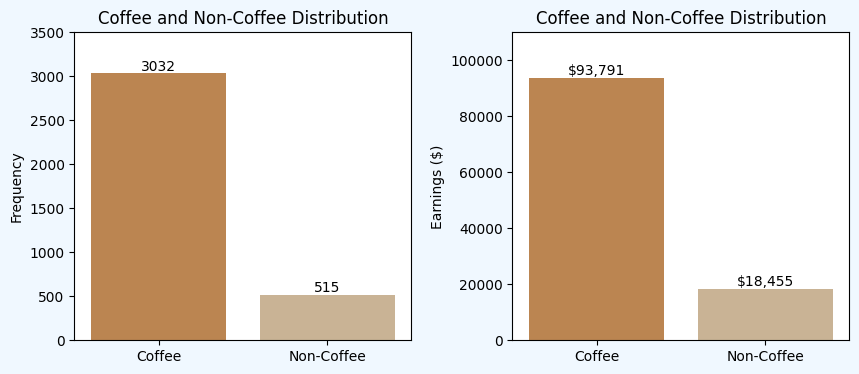

In [9]:
# Plotting graphs
plt.figure(figsize = (10, 4), facecolor = 'aliceblue')
plt.subplots_adjust(wspace = 0.3)

# Count
plt.subplot(1,2,1)
ax1 = sns.countplot(data = df, x = 'coffee_yes', palette = ['peru', 'tan'])
plt.title('Coffee and Non-Coffee Distribution')
plt.xlabel('')
plt.ylabel('Frequency')
plt.ylim(0, 3500)
for container in ax1.containers:
    ax1.bar_label(container)

# Earnings
plt.subplot(1,2,2)
ax2 = sns.barplot(data = df, x = 'coffee_yes', y = 'money', estimator = np.sum, ci = None, palette = ['peru', 'tan'])
plt.title('Coffee and Non-Coffee Distribution')
plt.xlabel('')
plt.ylabel('Earnings ($)')
plt.ylim(0, 110000)
for container in ax2.containers:
    ax2.bar_label(container, fmt='${:,.0f}')  # format as integer
plt.show()

Coffee drinks are definitely more popular than non-coffee options. There are over 3000 orders for coffee but only 515 orders for non-coffee drinks. A total of over 90000 dollars have been earned by coffee drinks whereas only 18000 dollars are from non-coffee.

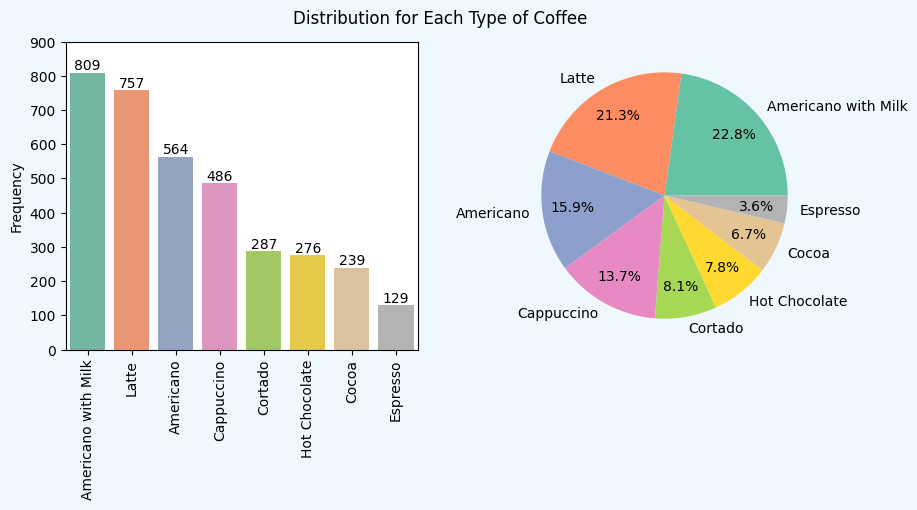

In [10]:
# Plotting distribution of coffee
plt.figure(figsize = (10,4), facecolor = 'aliceblue')
plt.suptitle('Distribution for Each Type of Coffee', y = 0.96)

# Barplot 
plt.subplot(1,2,1)
ax = sns.barplot(data = coffee, x = 'coffee_name', y = 'count', palette = 'Set2')
plt.xticks(rotation = 90)
plt.xlabel('')
plt.ylabel('Frequency')
plt.title('')
plt.ylim(0, 900)
for container in ax.containers:
    ax.bar_label(container, fmt="{:.0f}", fontsize=10) # Adding bar labels on top of bars

# Pie chart
plt.subplot(1,2,2)
plt.pie(data = coffee, x = 'count', autopct = '%1.1f%%', labels = 'coffee_name', colors = sns.color_palette("Set2", 8), pctdistance = 0.75)
plt.show()

The top 3 favourite orders are Americano with milk, Latte and plain Americano. The least popular drink is an Espresso. 

In [11]:
# Total earnings of coffee
coffee_money = df.groupby('coffee_name').money.sum().reset_index(name = 'total').sort_values(by = 'total', ascending = False)
coffee_money

,coffee_name,total
7,Latte,26875.30
1,Americano with Milk,24751.12
2,Cappuccino,17439.14
0,Americano,14650.26
6,Hot Chocolate,9933.46
3,Cocoa,8521.16
4,Cortado,7384.86
5,Espresso,2690.28


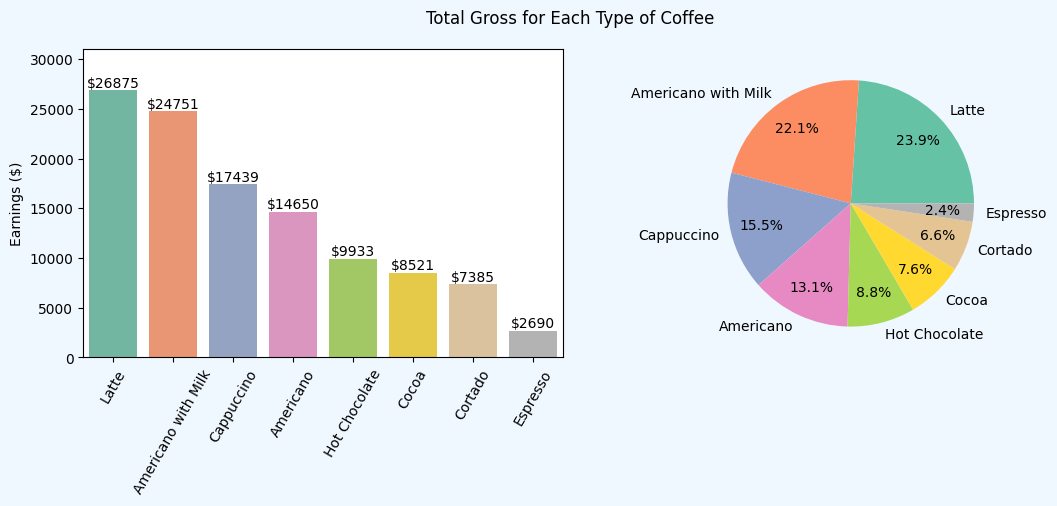

In [12]:
# Plotting earnings of coffees
plt.figure(figsize = (13,4), facecolor = 'aliceblue')
plt.suptitle('Total Gross for Each Type of Coffee')
plt.subplots_adjust(wspace = 0.1)

plt.subplot(1,2,1)
ax = sns.barplot(data = coffee_money, x = 'coffee_name', y = 'total', palette = 'Set2')
plt.ylabel('Earnings ($)')
plt.xticks(rotation = 60)
plt.xlabel('')
plt.ylim(0, 31000)
for container in ax.containers:
    ax.bar_label(container, fmt="${:.0f}", fontsize=10) # Adding bar labels on top of bars

plt.subplot(1,2,2)
plt.pie(data =coffee_money, x = 'total', labels = 'coffee_name', autopct = '%1.1f%%', pctdistance = 0.75, colors = sns.color_palette("Set2", 8))
    
plt.show()

The top 2 favourite drinks (Latte and Americano with milk) already account for around than 45% of the total earnings. 

In [45]:
# DateFrame for one year
df_year = df[(df.date >= '2024-03-01') & (df.date < '2025-03-01')]

# Popular drinks by season
df_year.groupby(['season']).coffee_name.value_counts().groupby(level=0).head(1).reset_index()

,season,coffee_name,count
0,Autumn,Latte,282
1,Spring,Americano with Milk,122
2,Summer,Americano with Milk,203
3,Winter,Americano with Milk,194


In terms of seasons, Latte is the most popular in autumn and an Americano with Milk is popular in spring, summer and winter.

### Data Question 2: Which time of year has the highest sales and are they significiantly different to each other?

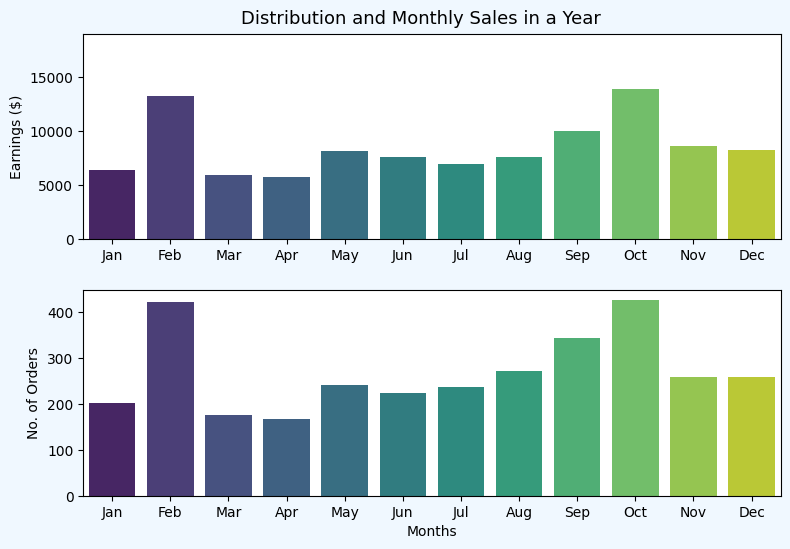

In [46]:
# Plotting monthly sales and earnings
plt.figure(figsize = (9,6), facecolor = 'aliceblue')
plt.suptitle('Distribution and Monthly Sales in a Year', y = 0.92, fontsize = 13)
plt.subplots_adjust(hspace = 0.25)

plt.subplot(2,1,1)
sns.barplot(data = df_year, x = 'month_num', y = 'money', estimator = np.sum, ci = None, palette = sns.color_palette("viridis", 12))
plt.xticks(ticks = np.arange(12), labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.ylabel('Earnings ($)')
plt.ylim(0, 19000)
plt.xlabel('')

plt.subplot(2,1,2)
sns.countplot(data = df_year, x = 'month_num', palette = sns.color_palette("viridis", 12))
plt.xticks(ticks = np.arange(12), labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.xlabel('Months')
plt.ylabel('No. of Orders')

plt.show()

Unsurprisingly, the trend for number of customers and earnings are the same. October had the highest sales, followed by February. It seems that sales and number of customers increases gradually throughout the year, especially from March to October. November and December decreased in sales significantly, in comparision to October.

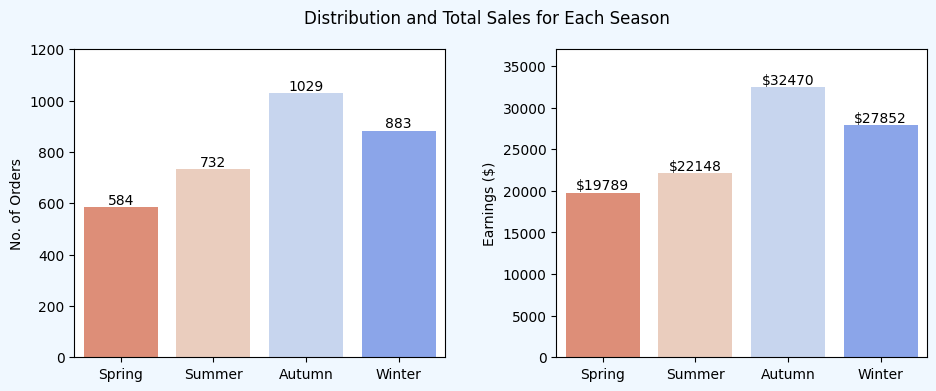

In [47]:
# Plotting seasonal sales and earnings
plt.figure(figsize = (11,4), facecolor = 'aliceblue')
plt.suptitle('Distribution and Total Sales for Each Season')
plt.subplots_adjust(wspace = 0.3)

plt.subplot(1,2,1)
ax1 = sns.countplot(data = df_year, x = 'season', palette = 'coolwarm_r')
plt.xlabel('')
plt.ylabel('No. of Orders')
plt.ylim(0, 1200)
for container in ax1.containers:
    ax1.bar_label(container, fmt="{:.0f}", fontsize=10) # Adding bar labels on top of bars

plt.subplot(1,2,2)
ax2 = sns.barplot(data = df_year, x = 'season', y = 'money', estimator = np.sum, palette = 'coolwarm_r', ci =None)
plt.ylabel('Earnings ($)')
plt.xlabel('')
plt.ylim(0, 37000)
for container in ax2.containers:
    ax2.bar_label(container, fmt="${:.0f}", fontsize=10) # Adding bar labels on top of bars
plt.show()

Autumn seems to be the most popular in terms of earnings compared to other seasons, with over 30,000 dollars in gross earnings. Winter was the second most popular season, followed by summer and spring. 

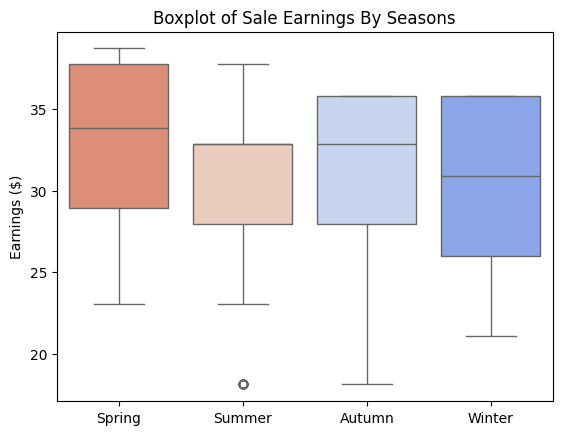

In [16]:
# Boxplot of seasonal earnings
sns.boxplot(data = df_year, x = 'season', y = 'money', palette = 'coolwarm_r')
plt.ylabel('Earnings ($)')
plt.xlabel('')
plt.title('Boxplot of Sale Earnings By Seasons')
plt.show()

The boxplot of earnings for each season seem to differ noticeably. The median earnings for spring, summer, autumn and winter fall between 32 to 34 dollars, with spring having the highest median earnings and winter with the lowest. Spring also has the highest earnings recorded with approximately 38 dollars.  Autumn has the lowest minimum earnings recorded of about 18 dollars. The distribution of earnings for summer is significantly lower whereas winter has the largest distribution.

In [17]:
# OLS
ols_formula = 'money ~ C(season)'
model = ols(formula = ols_formula, data = df_year).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  money   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.056
Method:                 Least Squares   F-statistic:                     64.23
Date:                Tue, 16 Sep 2025   Prob (F-statistic):           2.46e-40
Time:                        13:26:40   Log-Likelihood:                -9611.6
No. Observations:                3228   AIC:                         1.923e+04
Df Residuals:                    3224   BIC:                         1.926e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              31.5552      0.148    212.866      0.000      31.265      31.846
C(season)[T.Spring]     2.3303      0.246      9.459      0.000       1.847       2.813
C(season)[T.Summer]    -1.2990      0.230     -5.650      0.000      -1.750      -0.848
C(season)[T.Winter]    -0.0127      0.218     -0.058      0.954      -0.440       0.415
==============================================================================
Omnibus:                      343.536   Durbin-Watson:                   1.473
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              240.778
Skew:                          -0.560   Prob(JB):                     5.20e-53
Kurtosis:                       2.269   Cond. No.                         4.36
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Null Hypothesis

$$H_0: earnings_{summer}=earnings_{spring}=earnings_{autumn}=earnings_{winter}$$

There is a no difference in earnings among the days of the week.

#### Alternative Hypothesis

$$H_1: \text{Not } earnings_{summer}=earnings_{spring}=earnings_{autumn}=earnings_{winter}$$

Since the p-value is below the significance threshold of 0.05, we can reject the null hypothesis and accept the alternative hypothesis. This means that there is a significant difference in earnings among the seasons.

In [18]:
# Pairwise TukeyHSD
tukey_oneway = pairwise_tukeyhsd(endog = df_year['money'], groups = df_year['season'])
tukey_oneway.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
Autumn,Spring,2.3303,0.0,1.6971,2.9636,True
Autumn,Summer,-1.299,0.0,-1.89,-0.708,True
Autumn,Winter,-0.0127,0.9999,-0.5734,0.548,False
Spring,Summer,-3.6294,0.0,-4.3075,-2.9512,True
Spring,Winter,-2.343,0.0,-2.9949,-1.6911,True
Summer,Winter,1.2864,0.0,0.6754,1.8973,True


From results above, the `reject` column is `True` for all rows, except for autumn and winter. Hence, we can come to a conclusion that there is a significant difference between each season, excluding autumn and winter.

### Data Question 3: How are the sales throughout the day?

In [30]:
# Plotting histogram of hourly sales
# sns.countplot(data = df, x = 'hour_of_day', palette = 'RdBu')
# plt.title('Distribution of Sales By Hour of Day')
# plt.ylabel('Frequency')
# plt.xlabel('Hour of Day')
# plt.show()

There are two peaks in the number of sales throughout the day; at 10am and 4pm with approximately 330 and 275 sales respectively. 

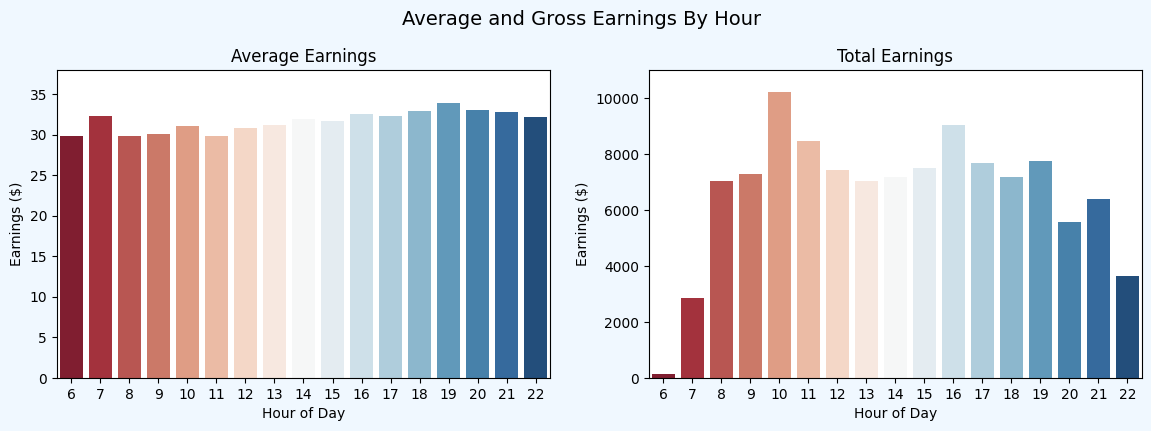

In [20]:
# Plotting average and total earnings 
plt.figure(figsize = (14,4), facecolor = 'aliceblue')

# Average earnings
plt.subplot(1,2,1)
plt.suptitle('Average and Gross Earnings By Hour', y = 1.03, fontsize = 14)
sns.barplot(data = df, x = 'hour_of_day', y = 'money', estimator = np.average, ci = None, palette = 'RdBu')
plt.xlabel('Hour of Day')
plt.ylabel('Earnings ($)')
plt.title('Average Earnings')
plt.ylim(0, 38)

# Total earnings
plt.subplot(1,2,2)
sns.barplot(data = df, x = 'hour_of_day', y = 'money', estimator = np.sum, ci = None, palette = 'RdBu')
plt.xlabel('Hour of Day')
plt.ylabel('Earnings ($)')
plt.title('Total Earnings')
plt.ylim(0, 11000)
plt.show()

The average earnings gradually increase throughout the day but there is also a peak around 7am. This could be due to high number of orders before people go to work. It then peaks around 7pm and decreases gradually after. For total earnings, there are two peaks at 10am and 4pm with approximately 10000 and 9000 dollars.

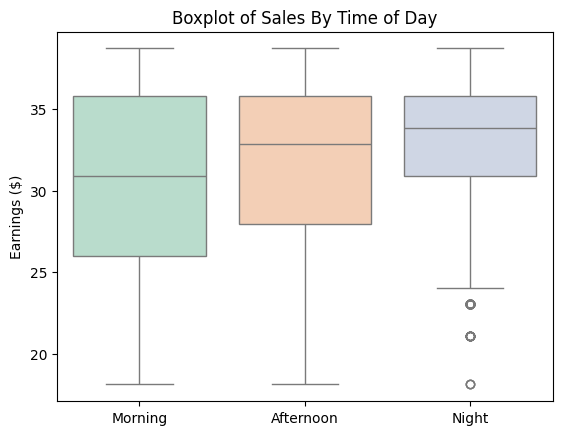

In [31]:
# Boxplot of sales by time
sns.boxplot(data = df, x = 'time_of_day', y = 'money', palette = 'Pastel2')
plt.xlabel('')
plt.ylabel('Earnings ($)')
plt.title('Boxplot of Sales By Time of Day')
plt.show()

The distribution of earnings in the morning is the largest, ranging from 26 to 36 dollars. The median earnings increases from morning to night, with 31, 33 and 34 dollars respectively. The maximum and minimum earnings are the same for morning and afternoon, whereas at night, its minimum is about 25 dollars. There are some outliers at night between 19 to 24 dollars. 

### Data Question 4: Is there a significant difference in sales between the days of the week?

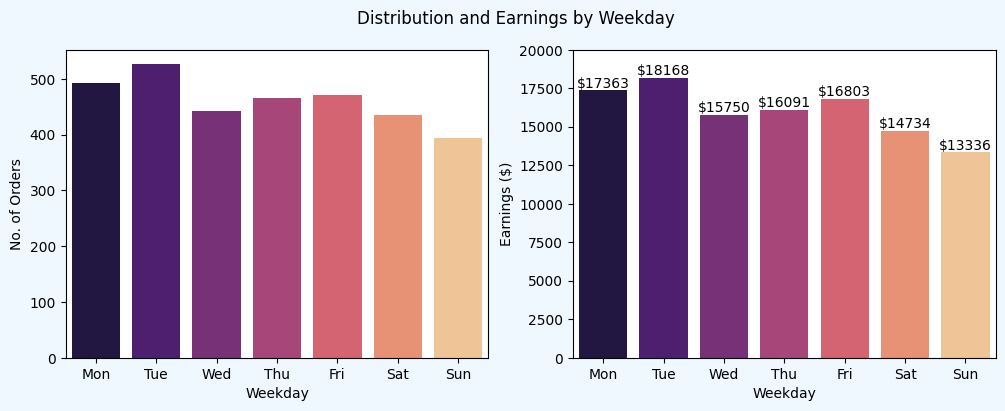

In [55]:
# Plotting sales by weekday
plt.figure(figsize = (12,4), facecolor = 'aliceblue')
plt.suptitle('Distribution and Earnings by Weekday')

plt.subplot(1,2,1)
sns.countplot(data = df_year, x = 'weekday_num', palette = sns.color_palette("magma", 7))
plt.ylabel('No. of Orders')
plt.xlabel('Weekday')
plt.xticks(ticks = np.arange(7), labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

plt.subplot(1,2,2)
ax1 = sns.barplot(data = df, x = 'weekday_num', y = 'money', ci = None,  estimator = np.sum , palette = sns.color_palette("magma", 7))
plt.xlabel('Weekday')
plt.ylabel('Earnings ($)')
plt.ylim(0, 20000)
plt.xticks(ticks = np.arange(7), labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
for container in ax1.containers:
    ax1.bar_label(container, fmt="${:.0f}", fontsize=10) # Adding bar labels on top of bars
    
plt.show()

In [23]:
# OLS
ols_formula = 'money ~ C(weekday)'
model = ols(formula = ols_formula, data = df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  money   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.8452
Date:                Tue, 16 Sep 2025   Prob (F-statistic):              0.535
Time:                        13:26:42   Log-Likelihood:                -10651.
No. Observations:                3547   AIC:                         2.132e+04
Df Residuals:                    3540   BIC:                         2.136e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            31.5839      0.212    149.329      0.000      31.169      31.999
C(weekday)[T.Mon]     0.3335      0.297      1.121      0.262      -0.250       0.917
C(weekday)[T.Sat]    -0.2360      0.309     -0.764      0.445      -0.842       0.369
C(weekday)[T.Sun]     0.2444      0.319      0.767      0.443      -0.380       0.869
C(weekday)[T.Thu]    -0.0322      0.302     -0.106      0.915      -0.625       0.561
C(weekday)[T.Tue]     0.1790      0.294      0.609      0.543      -0.397       0.755
C(weekday)[T.Wed]    -0.0830      0.304     -0.273      0.785      -0.679       0.513
==============================================================================
Omnibus:                      319.670   Durbin-Watson:                   1.426
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              239.566
Skew:                          -0.538   Prob(JB):                     9.53e-53
Kurtosis:                       2.320   Cond. No.                         7.71
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Null Hypothesis

$$H_0: sales_{mon}=sales_{tue}=sales_{wed}=sales_{thu}=sales_{fri}=sales_{sat}=sales_{sun}$$

There is a no difference in sales among the days of the week.

#### Alternative Hypothesis

$$H_1: \text{Not } sales_{mon}=sales_{tue}=sales_{wed}=sales_{thu}=sales_{fri}=sales_{sat}=sales_{sun}$$

In [24]:
sm.stats.anova_lm(model, typ = 1)

,df,sum_sq,mean_sq,F,PR(>F)
C(weekday),6.0,120.692276,20.115379,0.84523,0.534789
Residual,3540.0,84247.446034,23.798714,NaN,NaN


In [25]:
sm.stats.anova_lm(model, typ = 2)

,sum_sq,df,F,PR(>F)
C(weekday),120.692276,6.0,0.84523,0.534789
Residual,84247.446034,3540.0,NaN,NaN


In [26]:
sm.stats.anova_lm(model, typ = 3)

,sum_sq,df,F,PR(>F)
Intercept,530694.329089,1.0,22299.286369,0.000000
C(weekday),120.692276,6.0,0.845230,0.534789
Residual,84247.446034,3540.0,NaN,NaN


Since the p-value is more than the significance threshold (0.05), we can accept the null hypothesis which indicates that the sales for each weekday is not significant to each other and are equal to each other. 

In [27]:
# Performing Tukey One Way ANOVA with Type
tukey_oneway = pairwise_tukeyhsd(endog = df['money'], groups = df['weekday'])
tukey_oneway.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
Fri,Mon,0.3335,0.9218,-0.544,1.211,False
Fri,Sat,-0.236,0.9882,-1.1471,0.675,False
Fri,Sun,0.2444,0.988,-0.6956,1.1844,False
Fri,Thu,-0.0322,1.0,-0.924,0.8597,False
Fri,Tue,0.179,0.9966,-0.6879,1.0458,False
Fri,Wed,-0.083,1.0,-0.9794,0.8134,False
Mon,Sat,-0.5695,0.5114,-1.4758,0.3368,False
Mon,Sun,-0.0892,1.0,-1.0246,0.8463,False
Mon,Thu,-0.3657,0.8881,-1.2527,0.5213,False
Mon,Tue,-0.1546,0.9984,-1.0164,0.7073,False


Tukey's Pairwise Honestly Significant Difference (HSD) test compared the sales for each weekday and validates that there is no significant difference between the weekdays in terms of sales since the `reject` column is `False` for all rows. 

## Conclusion

This project focuses on a dataset that contains sales information of a cafe. The dataset was used to analyse and investigate the different trends in sales in coffee and non-coffee drinks throughout different times (months, weekdays, hourly). It was found that the most popular drink throughout the year, in terms of quantity, is an Americano with milk, followed by Lattes. Despite that, Lattes account for the highest earnings as it costs slightly more than an Americano. It was also discovered that February and October have the two highest sales count throughout the year. In terms of seasons, autumn has the highest earnings in sales and orders with winter as second. An ANOVA test was performed to determine if the earnings in each season is significantly difference and was confirmed that they were, excluding autumn with winter. Next, we analysed the hourly earnings and found that the average earnings increase gradually as the day goes by whereas for total earnings, it peaks at 10am and 4pm. Lastly, we investigated the significance in earnings among the weekdays and determined that there was no significant difference. 

## Next Steps

This section highlights improvements that the cafe can make to attract for customers and improve its overall sales. 

1. Coffees are definitely popular drinks to order in this cafe. Hence, it might be a good idea to expand its coffee selections (flat whites, babycinos, etc). This can offer more variety to customers and maintains their interest. 
2. Sales are slower during the middle of the year. Seasonal promotions such as mid-year sales  can be helplful to attract customers and boost sales.
3. Seasonal drinks, especially in the spring and summer, are also a good way to pique on-goers' interest and draw their attention.
4. Unsurprisingly, weekends have a lower sale than weekdays. Therefore, weekend deals could be used to increase its sales.